---

# Section 1: The preprocessing pipeline

> User-taken photos of their clothes are transformed into standardised images:
> 
> 1. Load raw image
> 2. Background removal  
> 3. Standardisation (colour boost, shadow reduction, sizing, centring)

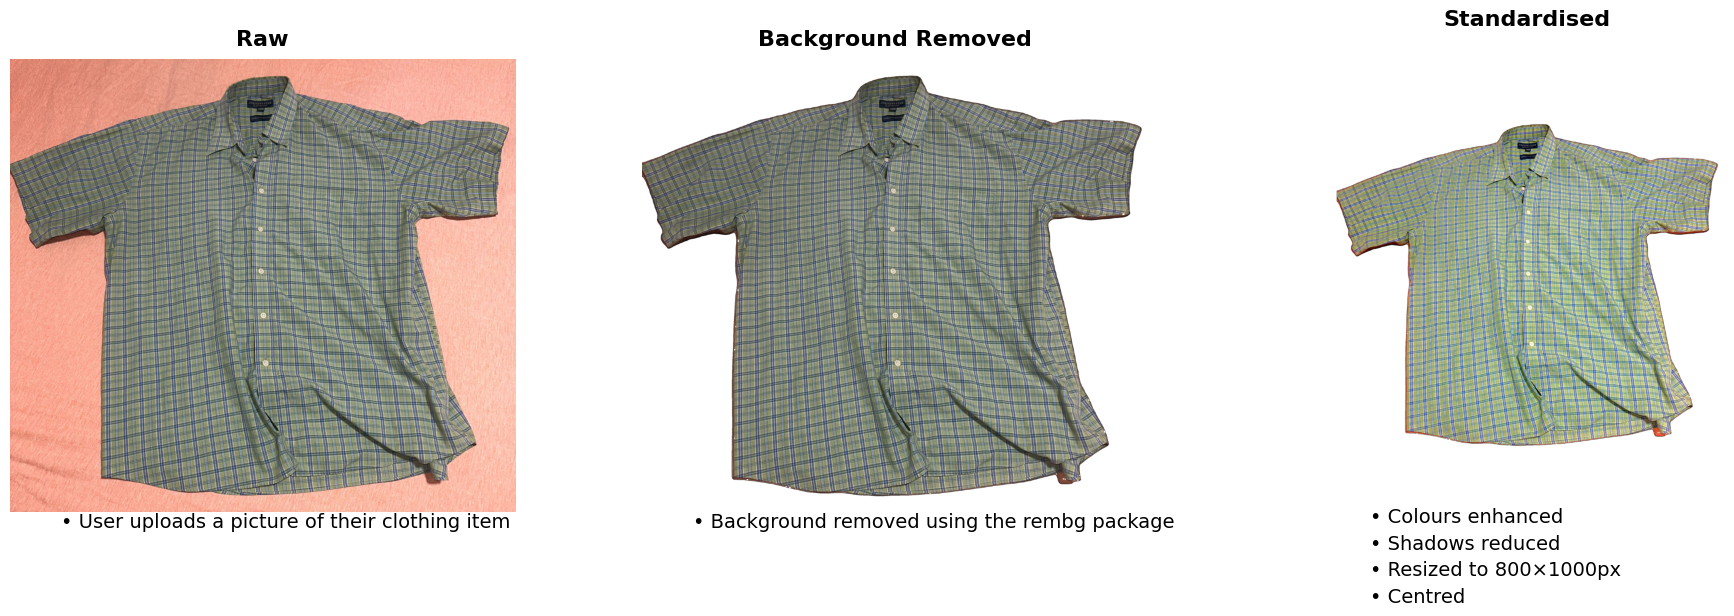

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

stages = [
    ("Raw", "data/wardrobe/1/raw_images/shirt_11.jpg"),
    ("Background Removed", "data/wardrobe/1/bg_removed/shirt_11_bg_removed.png"),
    ("Standardised", "data/wardrobe/1/processed_images/shirt_11_processed.png")
]

annotations = [
    "• User uploads a picture of their clothing item",
    "• Background removed using the rembg package",
    "• Colours enhanced\n• Shadows reduced\n• Resized to 800×1000px\n• Centred"
]

for ax, (title, path), annotation, y_pos in zip(axes, stages, annotations, [0, 0, 0.05]):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.axis('off')
    
    ax.text(0.1, y_pos, annotation, 
            transform=ax.transAxes,
            fontsize=14,
            ha='left',
            va='top',
            linespacing=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

---

# Section 2: Feature extraction

>Two feature extraction systems applied to clothing:
>
>1. computer vision - quantitative colour, texture, and pattern metrics
>2. genAI (Claude) - semantic understanding of style, fit, and formality

• dominant colours are extracted using k-means clustering on clothing pixels


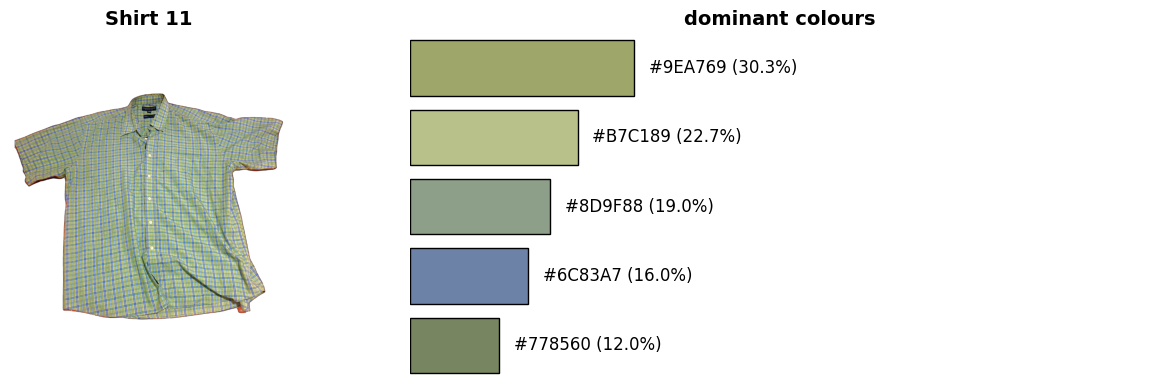

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from src.feature_extraction.cv_features import extract_dominant_colors
from PIL import Image

img = plt.imread("data/wardrobe/1/processed_images/shirt_11_processed.png")
dominant_colors = extract_dominant_colors(img, n_clusters=10, top_n=5)

print("• dominant colours are extracted using k-means clustering on clothing pixels")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.imshow(img)
ax1.set_title("Shirt 11", fontsize=14, fontweight='bold')
ax1.axis('off')

ax2.set_xlim(0, 1)
ax2.set_ylim(0, len(dominant_colors))
ax2.set_title("dominant colours", fontsize=14, fontweight='bold')
ax2.axis('off')

y_pos = len(dominant_colors) - 0.5
for hex_code, weight in dominant_colors:
    rect = patches.Rectangle((0, y_pos - 0.4), weight, 0.8, 
                             facecolor=hex_code, edgecolor='black', linewidth=1)
    ax2.add_patch(rect)
    
    ax2.text(weight + 0.02, y_pos, f"{hex_code} ({weight:.1%})", 
            va='center', fontsize=12)
    y_pos -= 1

plt.tight_layout()
plt.show()

In [39]:
from src.feature_extraction.cv_features import extract_all_features

print("• texture metrics are extracted using variance calculations")
print("• brightness/saturation/hue are extracted using HSV colour space analysis")

# Extract CV features from shirt_11
cv_features = extract_all_features("data/wardrobe/1/processed_images/shirt_11_processed.png")

print("\nComputer Vision Features:")
print("=" * 50)
for key, value in cv_features.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.3f}")
    else:
        print(f"{key:20s}: {value}")

• texture metrics are extracted using variance calculations
• brightness/saturation/hue are extracted using HSV colour space analysis

Computer Vision Features:
dominant_color      : #9EA769
secondary_color     : #B7C189
avg_brightness      : 0.596
avg_saturation      : 0.300
avg_hue             : 0.345
color_variance      : 1080.140
edge_density        : 0.370
texture_contrast    : 1011.254


In [40]:
from src.feature_extraction.genai_features import extract_genai_features

genai_features = extract_genai_features("data/wardrobe/1/processed_images/shirt_11_processed.png")
print("• prompt includes upload of the image and a structured classification request")
print("• claude returns json with specific fields (style, fit, formality, etc.)")
      
print("\ngenAI features:")
print("=" * 50)
for key, value in genai_features.items():
    if key == 'color_description':  # Skip this field
        continue
    if isinstance(value, float):
        print(f"{key:20s}: {value:.2f}")
    else:
        print(f"{key:20s}: {value}")

• prompt includes upload of the image and a structured classification request
• claude returns json with specific fields (style, fit, formality, etc.)

genAI features:
pattern_type        : checkered
has_graphic         : False
style               : business
fit_type            : regular
formality_score     : 0.70
versatility_score   : 0.80
season_suitability  : all_season


---

# Section 3: The database

An SQLite database is used to store the data

Core tables:
- `wardrobe_items` - Clothing items with CV features
- `genai_features` - Semantic features from Claude
- `outfit_ratings` - User ratings (training data)
- `outfit_features` - Cached engineered features
- `outfit_predictions` - Cached ML predictions
- `model_versions` - Model training history

In [53]:
import pandas as pd

print("wardrobe_items table (first 3 rows):")
print("=" * 80)

items = db.get_wardrobe_items(user_id)[:3]
items_df = pd.DataFrame(items)

display_cols = ['clothing_id', 'item_type', 'dominant_color', 'secondary_color', 
                'avg_brightness', 'avg_saturation', 'uploaded_at']
display_cols = [col for col in display_cols if col in items_df.columns]

print(items_df[display_cols].to_string(index=False))

print("\ngenai_features table (first 3 rows):")
print("=" * 80)

genai_data = db.get_genai_features(user_id)[:3]
genai_df = pd.DataFrame(genai_data)

display_cols = ['clothing_id', 'pattern_type', 'style', 'fit_type', 
                'formality_score', 'versatility_score', 'season_suitability']
display_cols = [col for col in display_cols if col in genai_df.columns]

print(genai_df[display_cols].to_string(index=False))

print("\noutfit_ratings table (first 3 rows):")
print("=" * 80)

ratings = db.get_all_ratings(user_id)[:3]
ratings_df = pd.DataFrame(ratings)

display_cols = ['shirt_id', 'pants_id', 'shoes_id', 'rating', 'rating_source', 'rated_at']
display_cols = [col for col in display_cols if col in ratings_df.columns]

if 'rated_at' in ratings_df.columns:
    ratings_df['rated_at'] = ratings_df['rated_at'].str[:10]

print(ratings_df[display_cols].to_string(index=False))

wardrobe_items table (first 3 rows):
clothing_id item_type dominant_color secondary_color  avg_brightness  avg_saturation         uploaded_at
    pants_1     pants        #1E4C7C         #345175        0.330776        0.559215 2025-09-28 02:18:47
   pants_10     pants        #675D57         #6F645D        0.372783        0.166762 2025-09-28 02:18:37
   pants_11     pants        #414A34         #4C543E        0.285750        0.307730 2025-09-28 02:18:40

genai_features table (first 3 rows):
clothing_id pattern_type  style fit_type  formality_score  versatility_score season_suitability
   pants_10        plain casual    loose              0.2                0.6             summer
   pants_11        plain casual  regular              0.3                0.7               fall
   pants_12        plain casual    loose              0.2                0.6             summer

outfit_ratings table (first 3 rows):
shirt_id pants_id shoes_id  rating rating_source   rated_at
 shirt_5  pants_3  shoe

In [52]:
print("\nmodel_versions table (first 3 rows):")
print("=" * 80)

with db.get_connection() as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT version, training_samples, accuracy_score, trained_at, is_active
        FROM model_versions
        WHERE user_id = ?
        ORDER BY trained_at DESC
        LIMIT 3
    """, (user_id,))
    
    models = [dict(row) for row in cursor.fetchall()]

models_df = pd.DataFrame(models)
models_df['trained_at'] = models_df['trained_at'].str[:16]
print(models_df.to_string(index=False))

print("\noutfit_features table (first 3 rows):")
print("=" * 80)

with db.get_connection() as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT outfit_hash, feature_version, created_at
        FROM outfit_features
        WHERE user_id = ?
        ORDER BY created_at DESC
        LIMIT 3
    """, (user_id,))
    
    features = [dict(row) for row in cursor.fetchall()]
    
if features:
    features_df = pd.DataFrame(features)
    features_df['created_at'] = features_df['created_at'].str[:16]
    print(features_df.to_string(index=False))

print("\noutfit_predictions table (first 3 rows):")
print("=" * 80)

with db.get_connection() as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT outfit_hash, model_version, predicted_rating, predicted_at
        FROM outfit_predictions
        WHERE user_id = ?
        ORDER BY predicted_at DESC
        LIMIT 3
    """, (user_id,))
    
    predictions = [dict(row) for row in cursor.fetchall()]
    
if predictions:
    predictions_df = pd.DataFrame(predictions)
    predictions_df['predicted_at'] = predictions_df['predicted_at'].str[:16]
    print(predictions_df.to_string(index=False))


model_versions table (first 3 rows):
           version  training_samples  accuracy_score       trained_at  is_active
v135_20251003_1004               135        0.629630 2025-10-03 00:05          1
v131_20251002_2308               131        0.666667 2025-10-02 13:08          1
v131_20251002_2307               131        0.814815 2025-10-02 13:08          1

outfit_features table (first 3 rows):
             outfit_hash feature_version       created_at
shirt_15_pants_4_shoes_1            v1.0 2025-09-29 05:50
shirt_15_pants_4_shoes_2            v1.0 2025-09-29 05:50
shirt_15_pants_4_shoes_3            v1.0 2025-09-29 05:50

outfit_predictions table (first 3 rows):
              outfit_hash      model_version  predicted_rating     predicted_at
shirt_10_pants_10_shoes_1 v135_20251003_1004          0.827335 2025-10-03 00:07
shirt_10_pants_10_shoes_2 v135_20251003_1004          0.636483 2025-10-03 00:07
shirt_10_pants_10_shoes_3 v135_20251003_1004          0.792403 2025-10-03 00:07


---

# Section 4: The ML models

user-specific random forest models learn personal style preferences through continuous outfit ratings.

>key features:
>- binary classification: "Will user rate this outfit 4-5 stars?"
>- class weighting (2:1) to handle imbalanced ratings
>- automatic retraining every 5 ratings

In [55]:
from data.database.models import WardrobeDB
import pandas as pd

db = WardrobeDB("data/database/threaded.db")
user_id = 1

model_info = db.get_active_model_version(user_id)
ratings = db.get_all_ratings(user_id)

print("current model performance:")
print("=" * 70)
print(f"Model version       : {model_info['version']}")
print(f"Training samples    : {model_info['training_samples']} ratings")
print(f"Test accuracy       : {model_info['accuracy_score']:.1%}")
print(f"Trained at          : {model_info['trained_at'][:16]}")

print("\n\ntop 10 Most Important Features:")
print("=" * 70)
feature_importance = [
    ('overall_color_harmony', 0.0842),
    ('avg_formality', 0.0721),
    ('palette_distance', 0.0615),
    ('shirt_L * pants_L', 0.0534),
    ('formality_variance', 0.0489),
    ('shirt_saturation^2', 0.0423),
    ('shoes_versatility_score', 0.0401),
    ('shirt_a * pants_a', 0.0387),
    ('avg_versatility', 0.0356),
    ('pants_texture_contrast', 0.0334),
]

for feature, importance in feature_importance:
    bar = '█' * int(importance * 400)
    print(f"{feature:<32} {importance:.4f} {bar}")

current model performance:
Model version       : v135_20251003_1004
Training samples    : 135 ratings
Test accuracy       : 63.0%
Trained at          : 2025-10-03 00:05


top 10 Most Important Features:
overall_color_harmony            0.0842 █████████████████████████████████
avg_formality                    0.0721 ████████████████████████████
palette_distance                 0.0615 ████████████████████████
shirt_L * pants_L                0.0534 █████████████████████
formality_variance               0.0489 ███████████████████
shirt_saturation^2               0.0423 ████████████████
shoes_versatility_score          0.0401 ████████████████
shirt_a * pants_a                0.0387 ███████████████
avg_versatility                  0.0356 ██████████████
pants_texture_contrast           0.0334 █████████████


In [58]:
print("model incrementally learns as new ratings are given:")
print("=" * 70)

# Get model history
models = db.get_model_versions(user_id, limit=10)
models_df = pd.DataFrame(models)
models_df['trained_at'] = models_df['trained_at'].str[:10]

display_cols = ['version', 'training_samples', 'accuracy_score', 'is_active']
print(models_df[display_cols].to_string(index=False))

# Calculate improvement
first_acc = models_df.iloc[-1]['accuracy_score']
latest_acc = models_df.iloc[0]['accuracy_score']
improvement = latest_acc - first_acc

model incrementally learns as new ratings are given:
           version  training_samples  accuracy_score  is_active
v135_20251003_1004               135        0.629630          1
v131_20251002_2308               131        0.666667          1
v131_20251002_2307               131        0.814815          1
v130_20251002_2047               130        0.346154          1
v125_20251002_1931               125        0.640000          1
v124_20251001_2244               124        0.680000          1
v120_20251001_2019               120        0.625000          1
v117_20251001_2017               117        0.750000          1
v115_20250930_2310               115        0.739130          1
v115_20250930_2304               115        0.608696          1


In [59]:
print("Recommendation Strategy:")
print("=" * 70)
print("\nWhen generating outfit recommendations:")
print()
print("1. Score all possible combinations using the trained model")
print(f"   ({model_info['training_samples']} ratings → {shirts * pants * shoes} combinations scored)")
print()
print("2. Recommendation mix:")
print("   • 95% - High-scoring outfits (ML predictions)")
print("   • 5% - Random exploration (discover new combinations)")
print()
print("3. User rates the outfit (1-5 stars)")
print()
print("4. Every 5 ratings → Automatic model retraining")
print()
print("This creates a continuous feedback loop of improvement!")

Recommendation Strategy:

When generating outfit recommendations:

1. Score all possible combinations using the trained model
   (135 ratings → 720 combinations scored)

2. Recommendation mix:
   • 95% - High-scoring outfits (ML predictions)
   • 5% - Random exploration (discover new combinations)

3. User rates the outfit (1-5 stars)

4. Every 5 ratings → Automatic model retraining

This creates a continuous feedback loop of improvement!


Mobile App Interface:


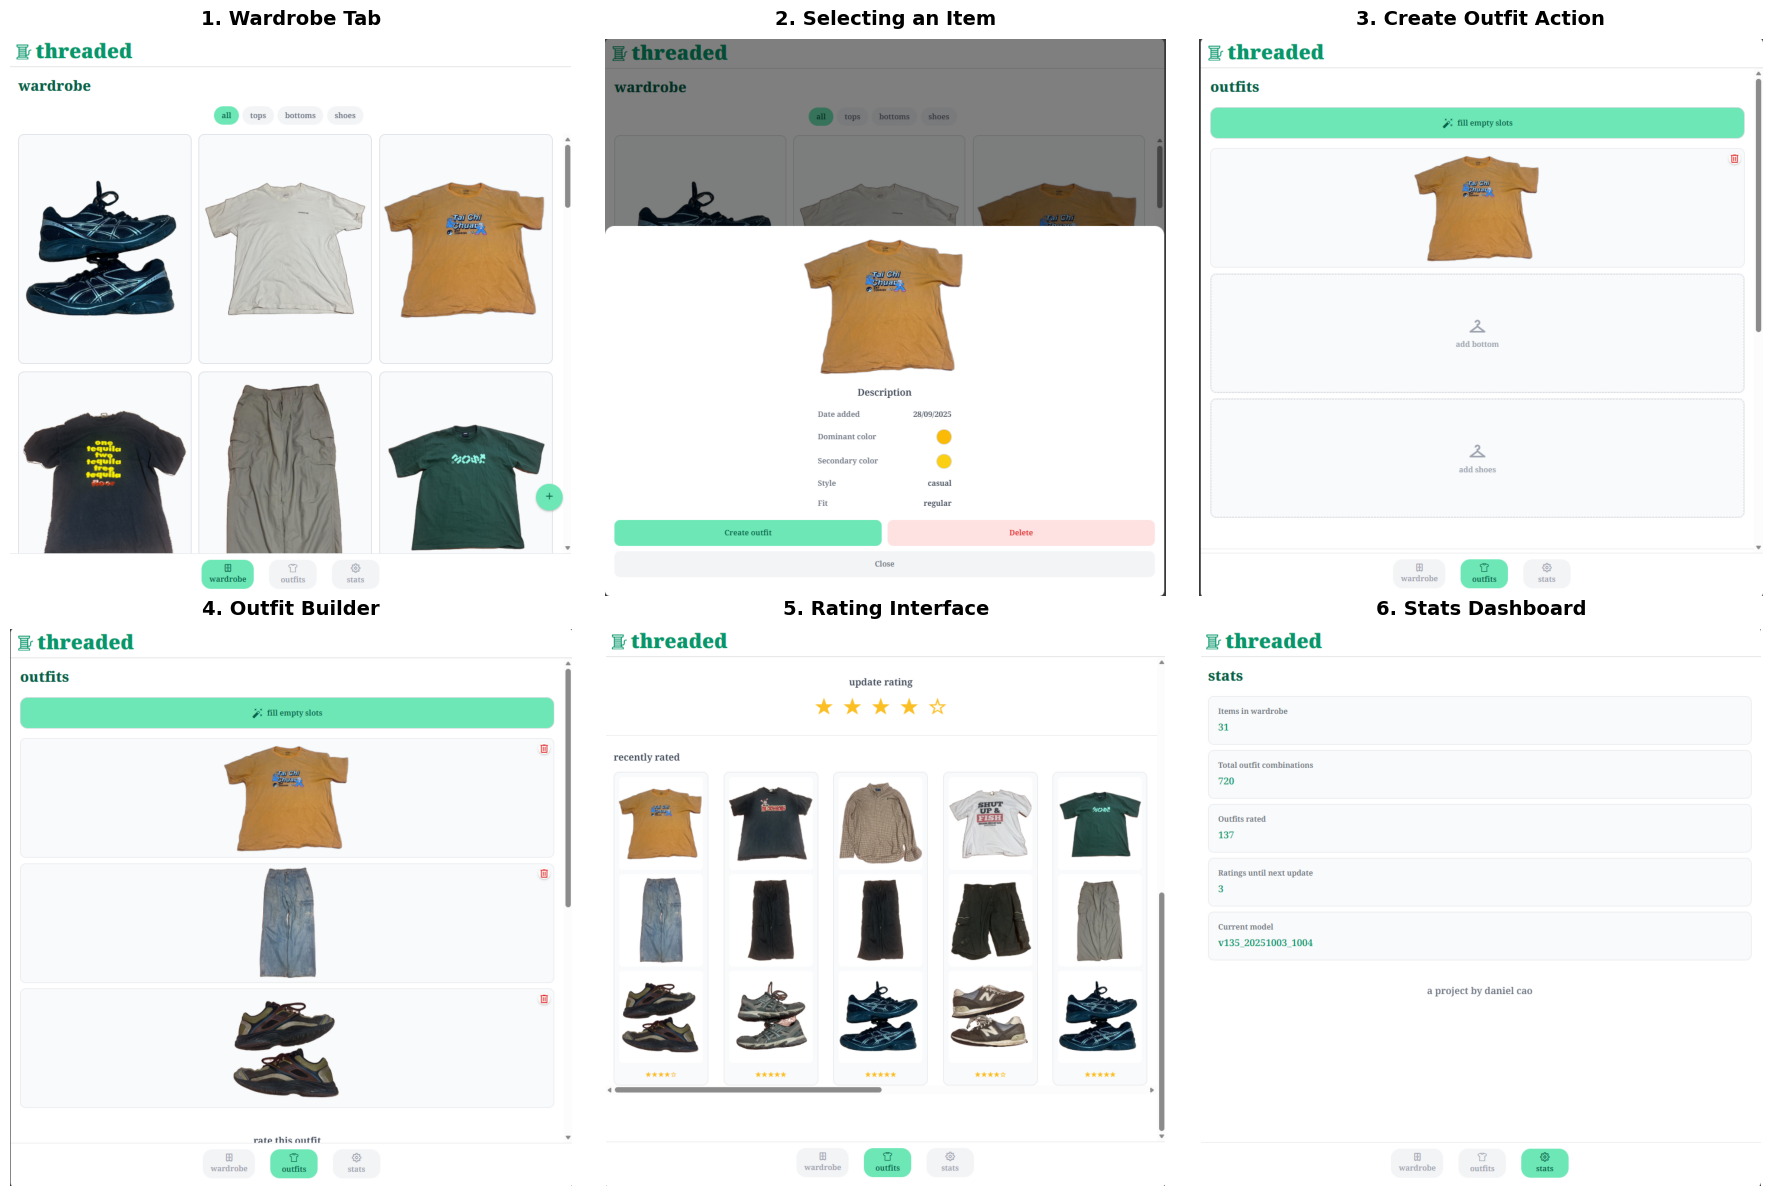

In [61]:
from PIL import Image
import matplotlib.pyplot as plt

print("Mobile App Interface:")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

screenshots = [
    ("1. Wardrobe Tab", "app_screenshots/image_1.png"),
    ("2. Selecting an Item", "app_screenshots/image_2.png"),
    ("3. Create Outfit Action", "app_screenshots/image_3.png"),
    ("4. Outfit Builder", "app_screenshots/image_4.png"),
    ("5. Rating Interface", "app_screenshots/image_5.png"),
    ("6. Stats Dashboard", "app_screenshots/image_6.png"),
]

for ax, (title, path) in zip(axes, screenshots):
    try:
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
        ax.axis('off')
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'{title}\n(file not found)', 
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.tight_layout()
plt.show()